<a href="https://colab.research.google.com/github/ReemaE-Git/Sleep-Apnea-Prediction/blob/main/notebooks/TCGA_panCan_main_primary_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
pd.set_option("display.max_columns", 200)

df = pd.read_csv("TCGA_panCan_cleaned_levels.csv")

target_cols = ["CD19","TNFRSF17","MS4A1","CD22","GPRC5D","SLAMF7","ERBB2","EGFR","MSLN","CD276"]
level_cols = [f"{g}_level" for g in target_cols]

df.head()


,sample,samples,TCGA_GTEX_main_category,_sample_type,_study,_primary_site,CD19,TNFRSF17,MS4A1,CD22,GPRC5D,SLAMF7,ERBB2,EGFR,MSLN,CD276,CD19_level,TNFRSF17_level,MS4A1_level,CD22_level,GPRC5D_level,SLAMF7_level,ERBB2_level,EGFR_level,MSLN_level,CD276_level,high_target_count,coexpress_2plus
0,TCGA-AB-2886-03,TCGA-AB-2886-03,TCGA Acute Myeloid Leukemia,Primary Blood Derived Cancer - Peripheral Blood,TCGA,White blood cell,12.33,4.073,9.604,8.995,1.214,7.567,7.711,1.214,7.191,4.466,High,Mid,High,High,Low,Mid,Low,Low,Mid,Low,3,Yes
1,TCGA-AB-2830-03,TCGA-AB-2830-03,TCGA Acute Myeloid Leukemia,Primary Blood Derived Cancer - Peripheral Blood,TCGA,White blood cell,11.47,6.059,11.580,10.510,1.337,9.109,8.492,2.480,0.000,5.549,High,High,High,High,Low,High,Low,Low,Low,Low,5,Yes
2,TCGA-AB-2875-03,TCGA-AB-2875-03,TCGA Acute Myeloid Leukemia,Primary Blood Derived Cancer - Peripheral Blood,TCGA,White blood cell,11.34,5.371,9.736,9.846,1.230,9.064,8.099,0.000,5.223,7.025,High,High,High,High,Low,High,Low,Low,Mid,Low,5,Yes
3,TCGA-AB-2858-03,TCGA-AB-2858-03,TCGA Acute Myeloid Leukemia,Primary Blood Derived Cancer - Peripheral Blood,TCGA,White blood cell,10.36,6.219,8.205,7.481,5.811,8.856,8.104,3.114,5.850,3.551,High,High,High,Mid,High,Mid,Low,Low,Mid,Low,4,Yes
4,TCGA-AB-2918-03,TCGA-AB-2918-03,TCGA Acute Myeloid Leukemia,Primary Blood Derived Cancer - Peripheral Blood,TCGA,White blood cell,10.36,4.144,7.866,8.085,1.132,7.490,6.979,2.799,1.132,4.766,High,Mid,High,Mid,Low,Mid,Low,Low,Low,Low,2,Yes


In [ ]:
# describe
df[target_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
CD19,17221.0,4.133062,2.519950,0.0,2.411,3.656,5.543,14.88
TNFRSF17,17221.0,3.016090,2.535761,0.0,1.068,2.416,4.839,14.40
MS4A1,17221.0,4.819730,3.047799,0.0,2.591,4.384,6.665,16.50
CD22,17221.0,7.120673,2.450161,0.0,5.395,6.991,8.690,15.77
GPRC5D,17221.0,3.332552,1.967222,0.0,1.965,3.330,4.550,14.41
SLAMF7,17221.0,6.862379,2.852826,0.0,4.729,7.009,9.005,16.03
ERBB2,17221.0,11.967827,1.799753,0.0,11.010,12.260,13.150,20.54
EGFR,17221.0,11.295717,2.323487,0.0,10.510,11.680,12.600,19.98
MSLN,17221.0,5.626358,4.037954,0.0,2.574,4.722,7.901,18.41
CD276,17221.0,11.143881,1.641638,0.0,10.550,11.380,12.110,17.06


In [ ]:
# cutoffs
q25 = df[target_cols].quantile(0.25)
q75 = df[target_cols].quantile(0.75)

cutoff_df = pd.DataFrame({
    "gene": target_cols,
    "q25_low_cutoff": [q25[g] for g in target_cols],
    "q75_high_cutoff": [q75[g] for g in target_cols]
})

cutoff_df


,gene,q25_low_cutoff,q75_high_cutoff
0,CD19,2.411,5.543
1,TNFRSF17,1.068,4.839
2,MS4A1,2.591,6.665
3,CD22,5.395,8.690
4,GPRC5D,1.965,4.550
5,SLAMF7,4.729,9.005
6,ERBB2,11.010,13.150
7,EGFR,10.510,12.600
8,MSLN,2.574,7.901
9,CD276,10.550,12.110


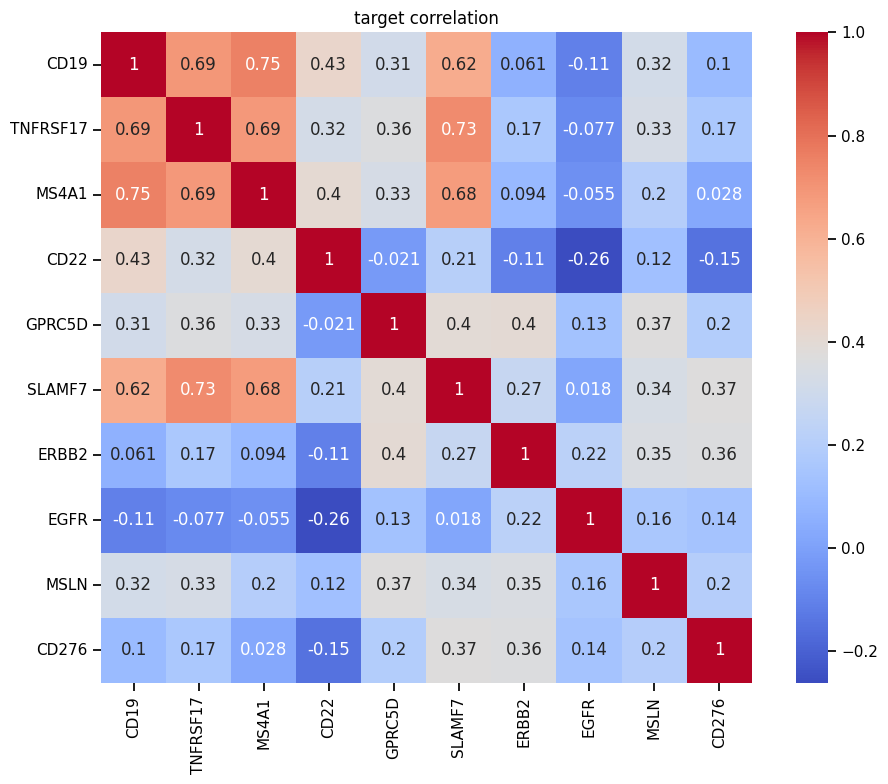

In [ ]:
# overall target correlation
plt.figure(figsize=(10,8))
corr = df[target_cols].corr(method="spearman")
sns.heatmap(corr, annot=True, cmap="coolwarm", square=True)
plt.title("target correlation")
plt.tight_layout()
plt.show()


In [ ]:
# long
long_df = df.melt(
    id_vars=["TCGA_GTEX_main_category","_primary_site","_sample_type","_study","high_target_count","coexpress_2plus"],
    value_vars=target_cols,
    var_name="gene",
    value_name="expr"
)

long_df.head()


,TCGA_GTEX_main_category,_primary_site,_sample_type,_study,high_target_count,coexpress_2plus,gene,expr
0,TCGA Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Peripheral Blood,TCGA,3,Yes,CD19,12.33
1,TCGA Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Peripheral Blood,TCGA,5,Yes,CD19,11.47
2,TCGA Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Peripheral Blood,TCGA,5,Yes,CD19,11.34
3,TCGA Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Peripheral Blood,TCGA,4,Yes,CD19,10.36
4,TCGA Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Peripheral Blood,TCGA,2,Yes,CD19,10.36


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_306/601633278.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


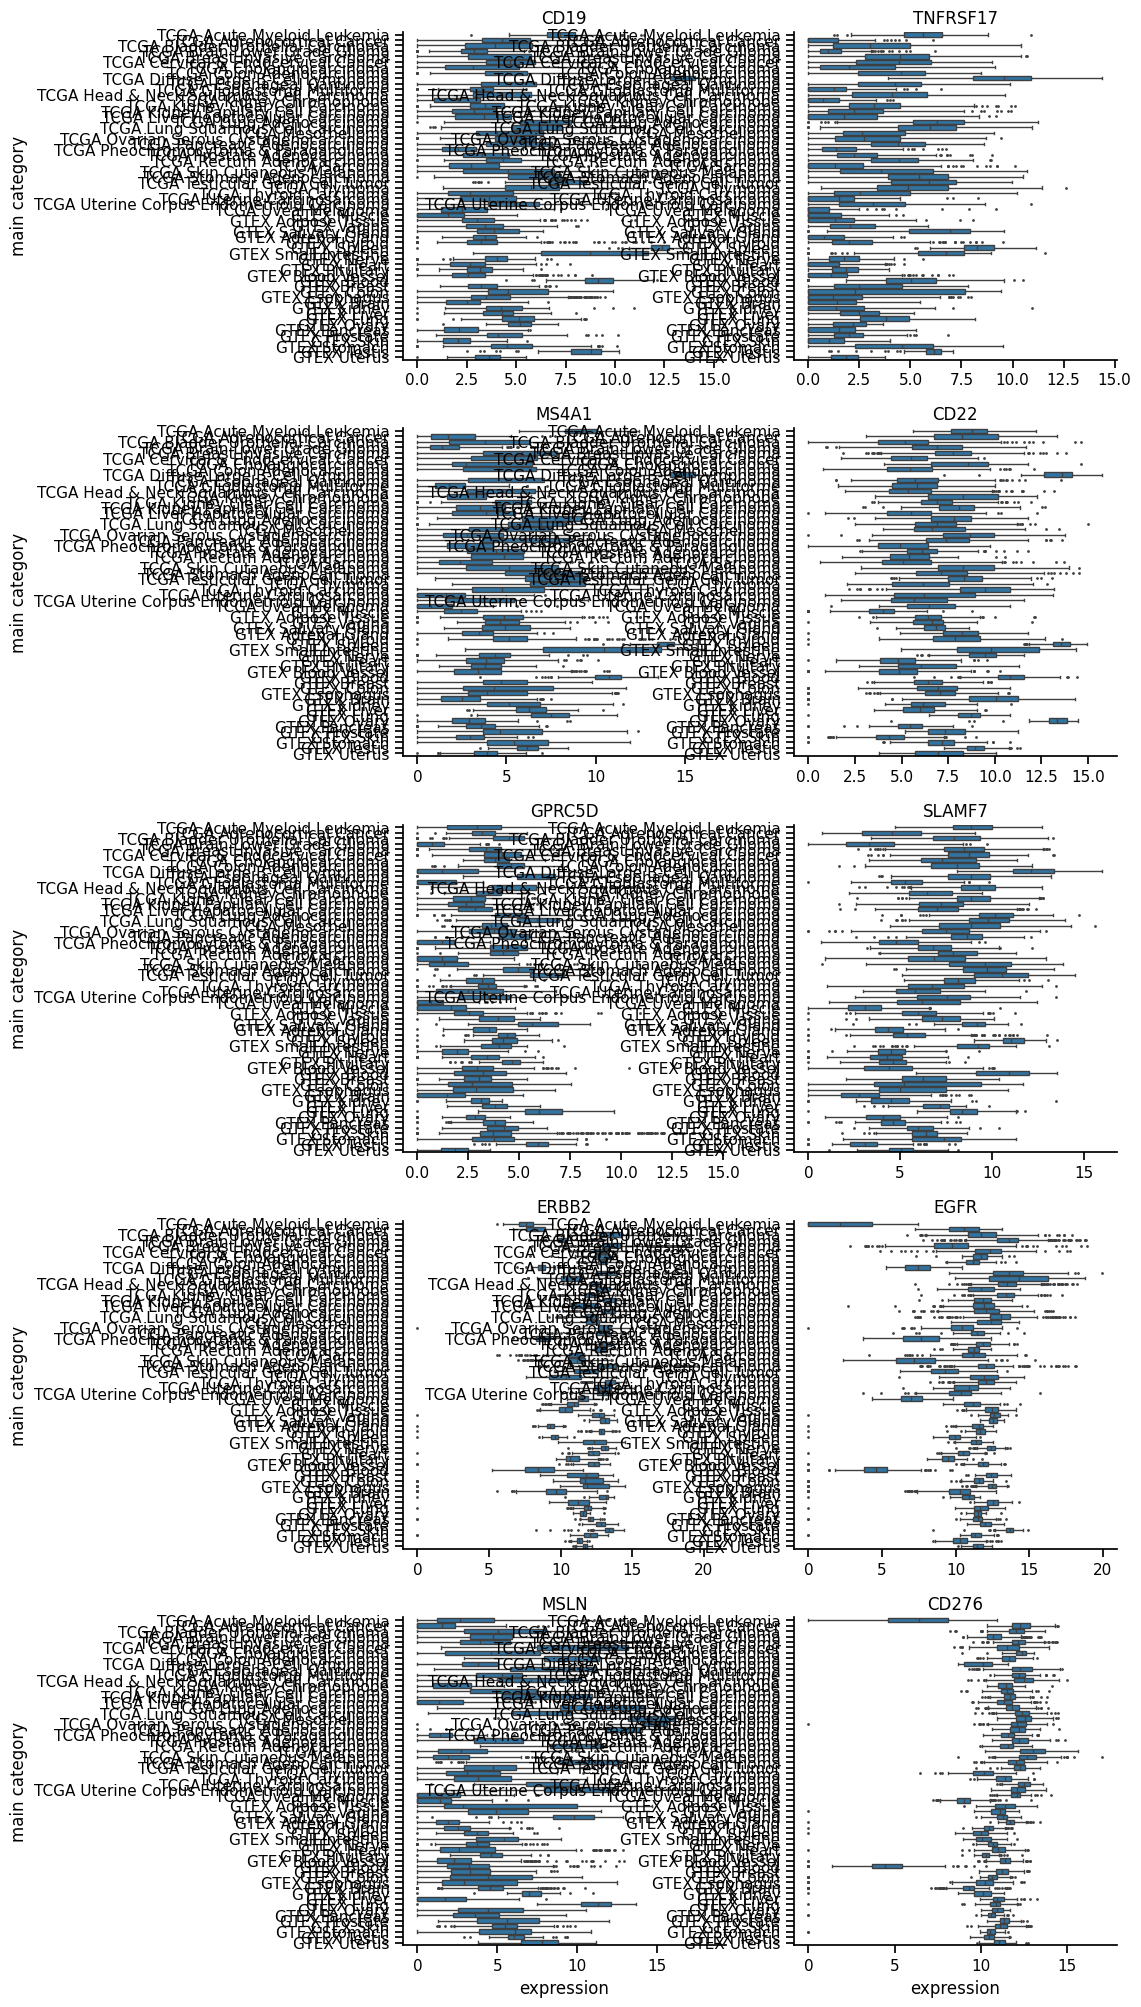

In [ ]:
# facet by main category
main_counts = df["TCGA_GTEX_main_category"].value_counts()
main_keep = main_counts[main_counts >= 20].index.tolist()

plot_main = long_df[long_df["TCGA_GTEX_main_category"].isin(main_keep)].copy()

g = sns.FacetGrid(plot_main, col="gene", col_wrap=2, sharex=False, sharey=False, height=4)
g.map_dataframe(sns.boxplot, x="expr", y="TCGA_GTEX_main_category", fliersize=1)
g.set_titles("{col_name}")
g.set_axis_labels("expression", "main category")
plt.tight_layout()
plt.show()


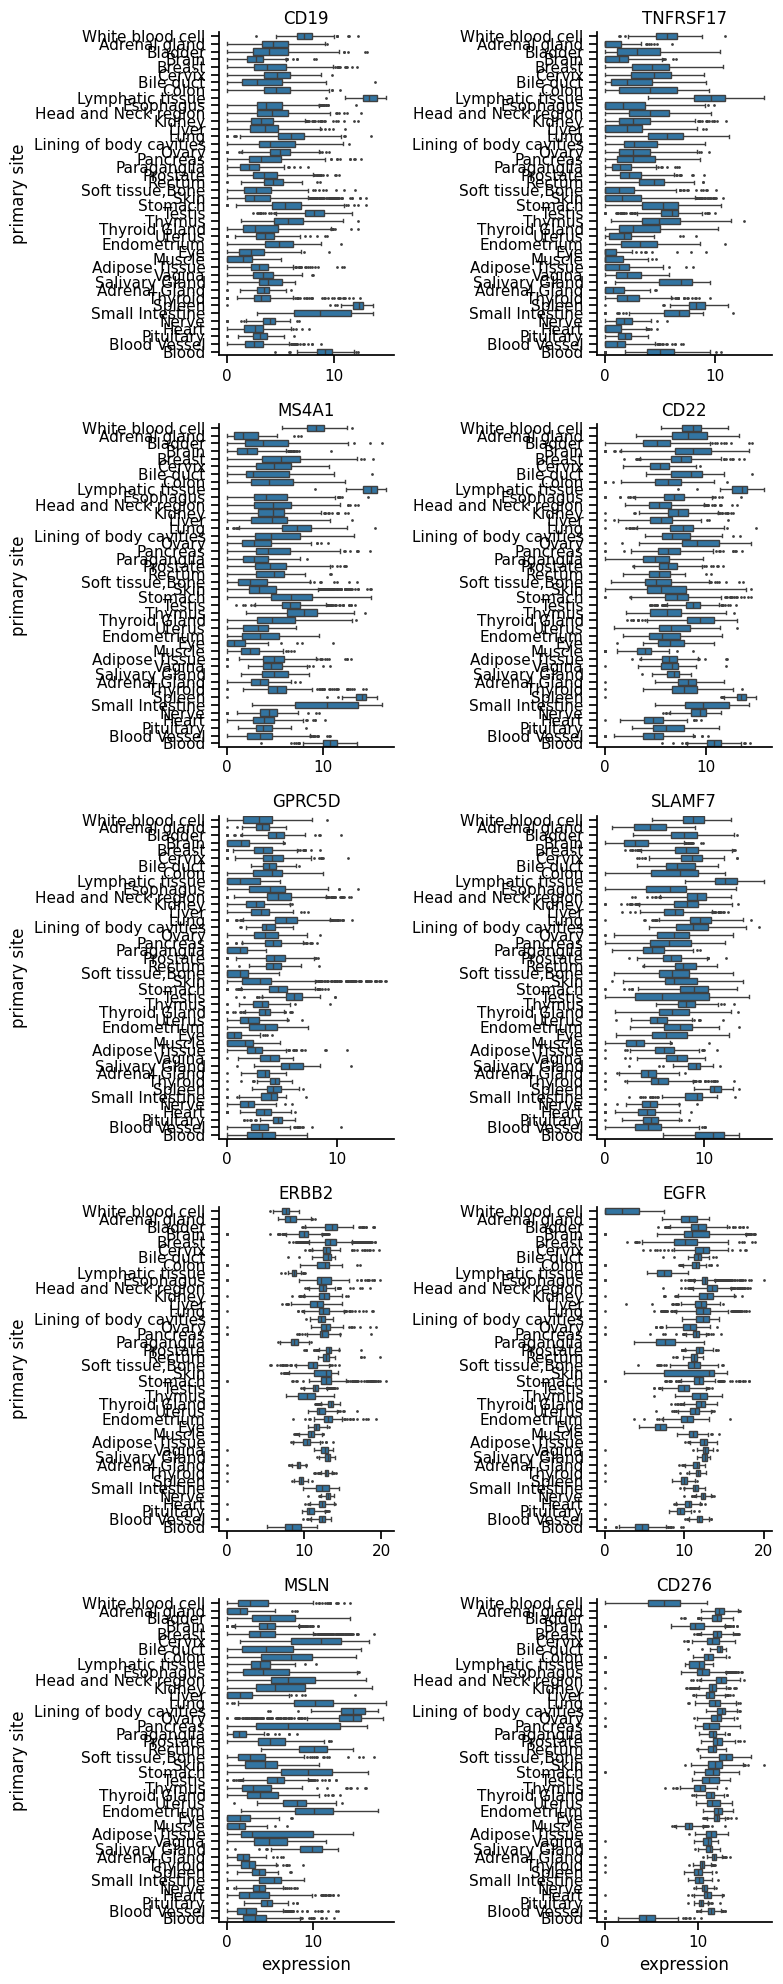

In [ ]:
# facet by primary site
site_counts = df["_primary_site"].value_counts()
site_keep = site_counts[site_counts >= 20].index.tolist()

plot_site = long_df[long_df["_primary_site"].isin(site_keep)].copy()

g = sns.FacetGrid(plot_site, col="gene", col_wrap=2, sharex=False, sharey=False, height=4)
g.map_dataframe(sns.boxplot, x="expr", y="_primary_site", fliersize=1)
g.set_titles("{col_name}")
g.set_axis_labels("expression", "primary site")
plt.tight_layout()
plt.show()


In [ ]:
# top main categories per target
main_rank = (
    long_df.groupby(["gene","TCGA_GTEX_main_category"], as_index=False)
    .agg(median_expr=("expr","median"), mean_expr=("expr","mean"), n=("expr","size"))
    .sort_values(["gene","median_expr"], ascending=[True,False])
)

top_main = main_rank.groupby("gene", as_index=False).head(10).reset_index(drop=True)
top_main.head(30)


,gene,TCGA_GTEX_main_category,median_expr,mean_expr,n
0,CD19,TCGA Diffuse Large B-Cell Lymphoma,13.3100,13.241085,47
1,CD19,GTEX Spleen,12.4000,12.135040,100
2,CD19,GTEX Blood,9.1560,9.125501,337
3,CD19,GTEX Testis,8.7840,8.445667,165
4,CD19,GTEX Small Intestine,8.7135,8.851663,92
5,CD19,TCGA Testicular Germ Cell Tumor,7.5625,7.507740,154
6,CD19,TCGA Acute Myeloid Leukemia,7.1940,7.371266,173
7,CD19,TCGA Lung Adenocarcinoma,6.4660,6.419047,515
8,CD19,TCGA Lung Squamous Cell Carcinoma,6.2495,6.065340,498
9,CD19,TCGA Stomach Adenocarcinoma,5.9760,6.013660,414


In [ ]:
# top primary sites per target
site_rank = (
    long_df.groupby(["gene","_primary_site"], as_index=False)
    .agg(median_expr=("expr","median"), mean_expr=("expr","mean"), n=("expr","size"))
    .sort_values(["gene","median_expr"], ascending=[True,False])
)

top_site = site_rank.groupby("gene", as_index=False).head(10).reset_index(drop=True)
top_site.head(30)


,gene,_primary_site,median_expr,mean_expr,n
0,CD19,Lymphatic tissue,13.3100,13.241085,47
1,CD19,Spleen,12.4000,12.135040,100
2,CD19,Blood,9.1560,9.125501,337
3,CD19,Small Intestine,8.7135,8.851663,92
4,CD19,Testis,8.1630,7.992875,319
5,CD19,White blood cell,7.1940,7.371266,173
6,CD19,Lung,6.0130,5.998398,1301
7,CD19,Thymus,5.7450,5.950437,119
8,CD19,Stomach,5.4910,5.661788,588
9,CD19,Ovary,4.9970,4.973318,515


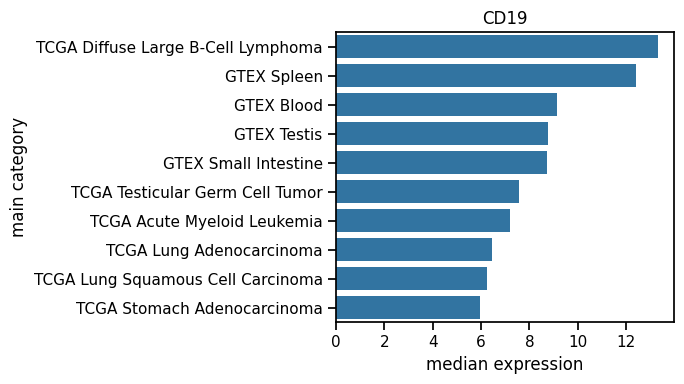

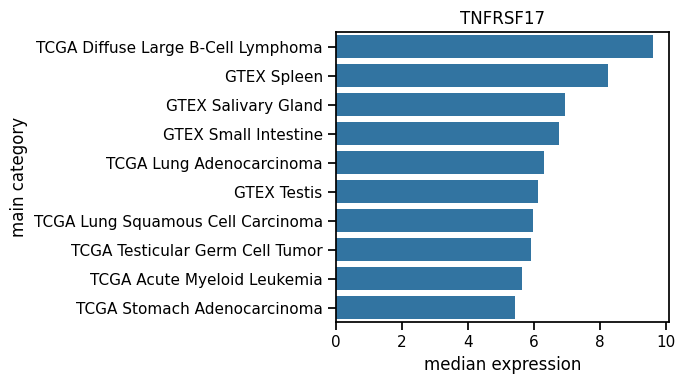

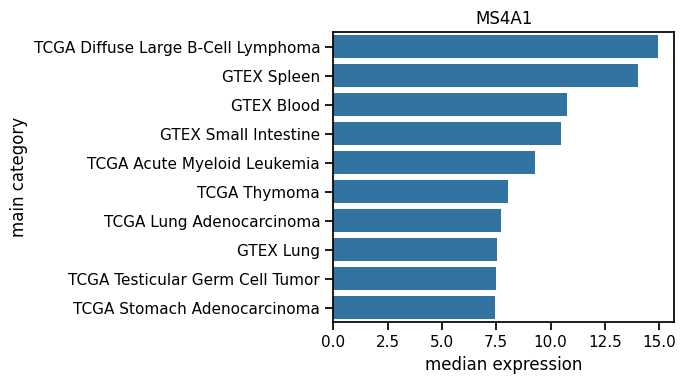

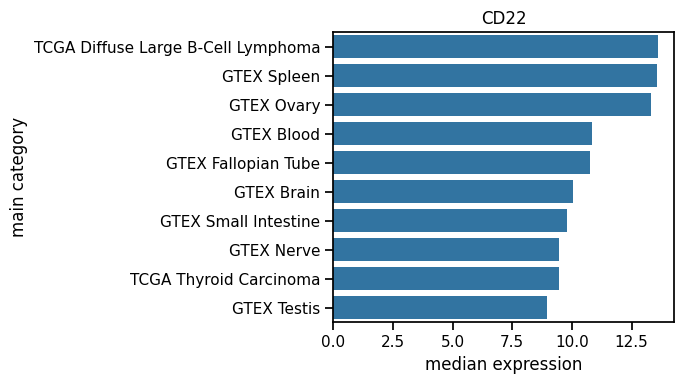

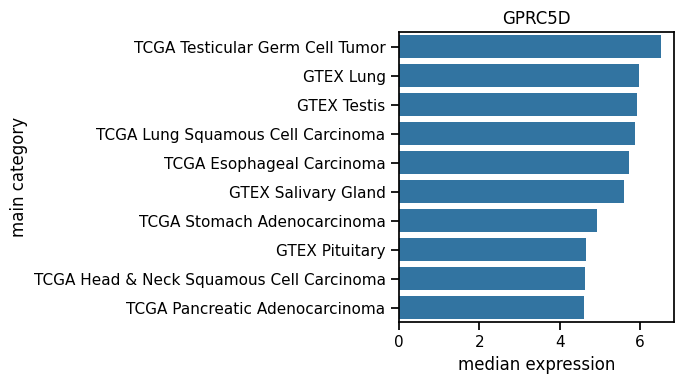

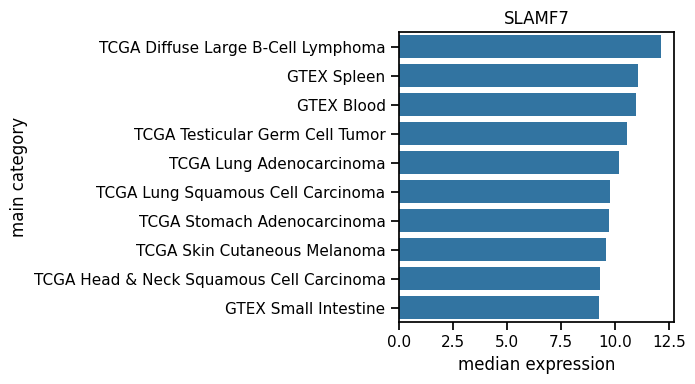

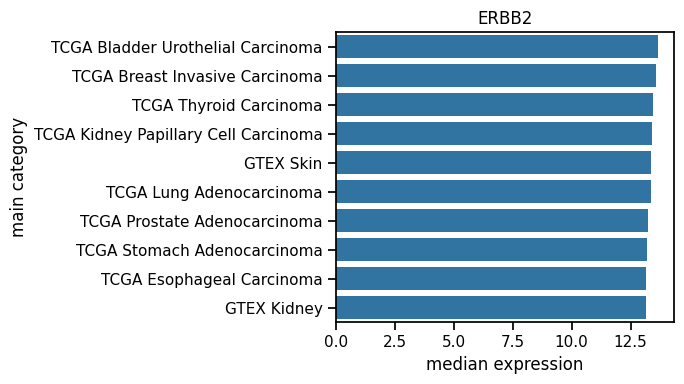

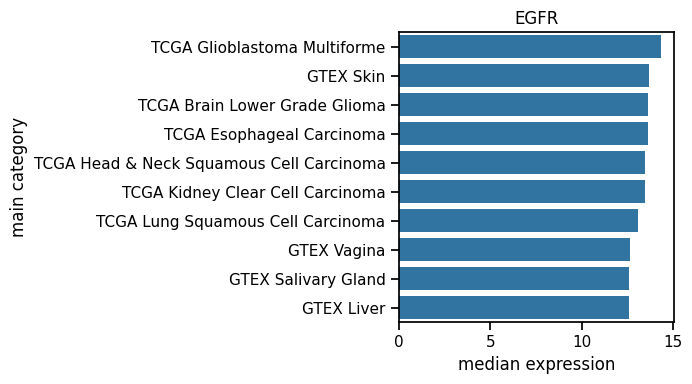

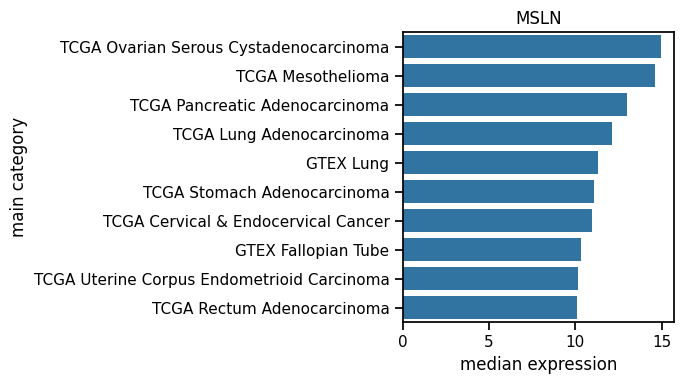

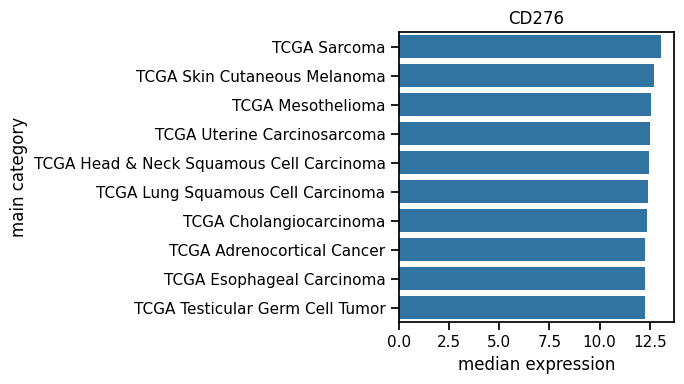

In [ ]:
# bar plots by main category
for g1 in target_cols:
    tmp = main_rank[main_rank["gene"] == g1].head(10).copy()
    plt.figure(figsize=(7,4))
    sns.barplot(data=tmp, x="median_expr", y="TCGA_GTEX_main_category")
    plt.title(g1)
    plt.xlabel("median expression")
    plt.ylabel("main category")
    plt.tight_layout()
    plt.show()


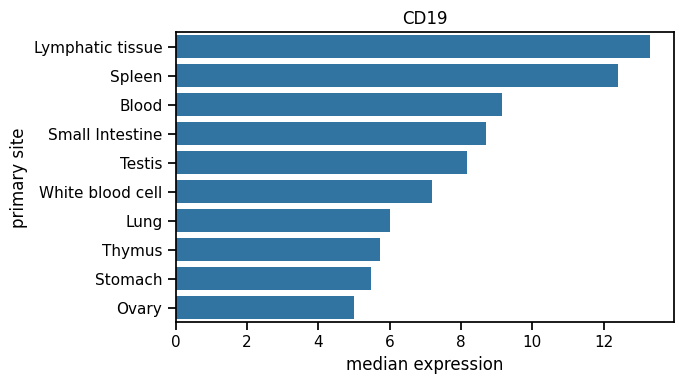

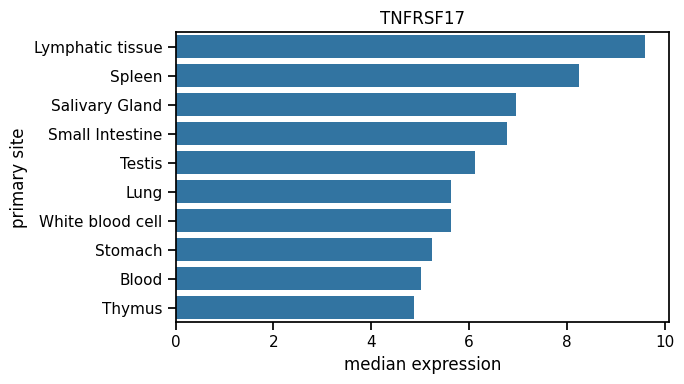

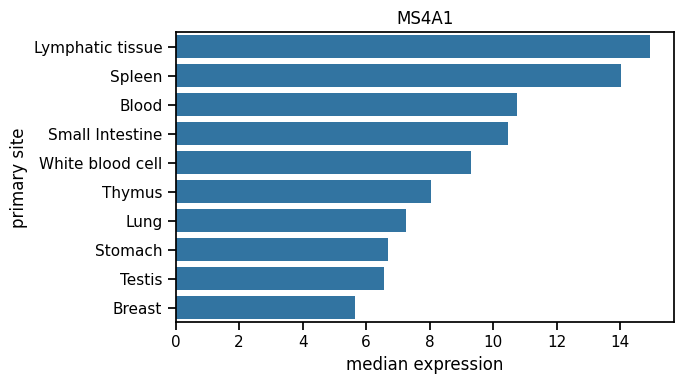

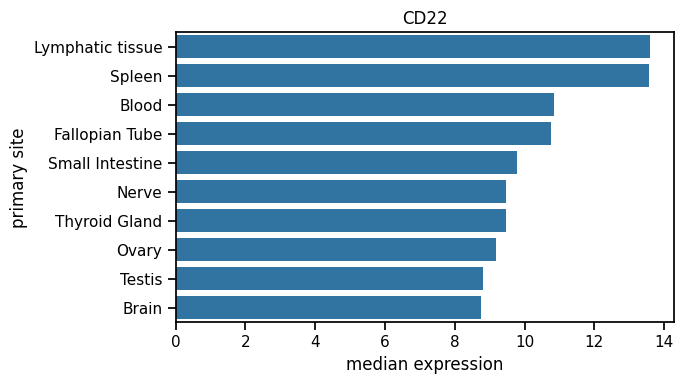

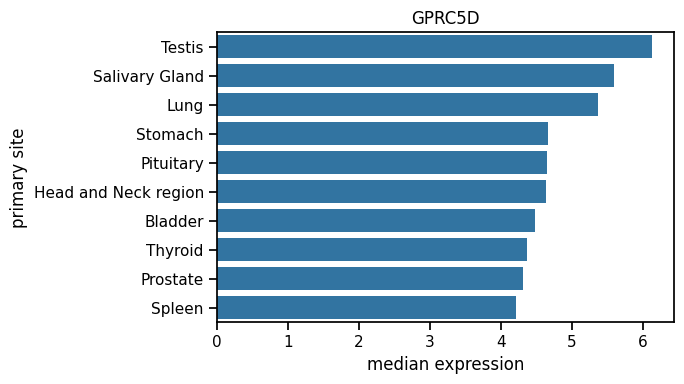

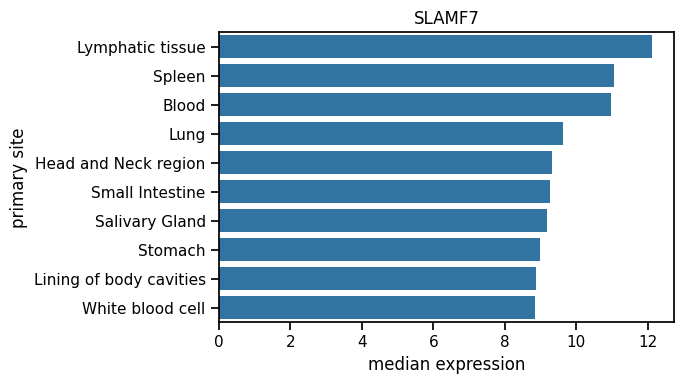

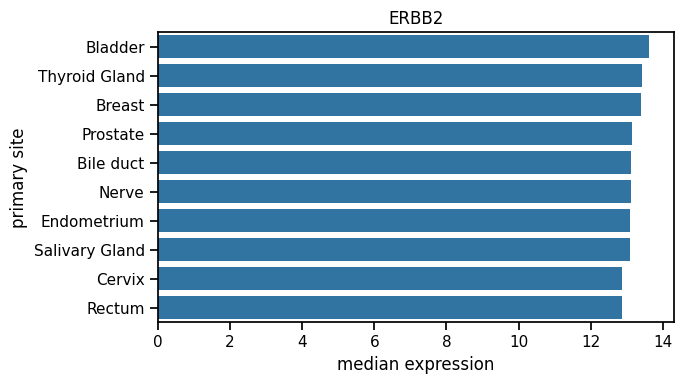

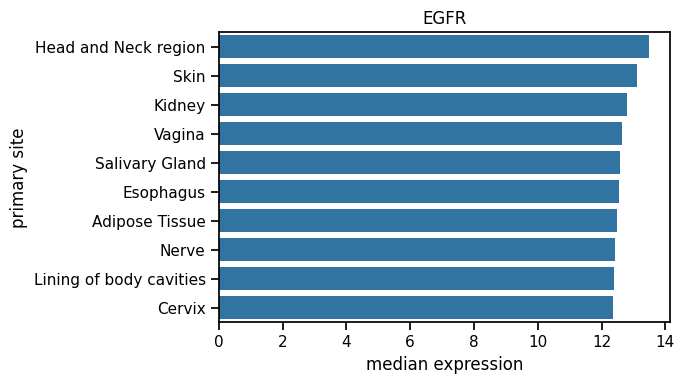

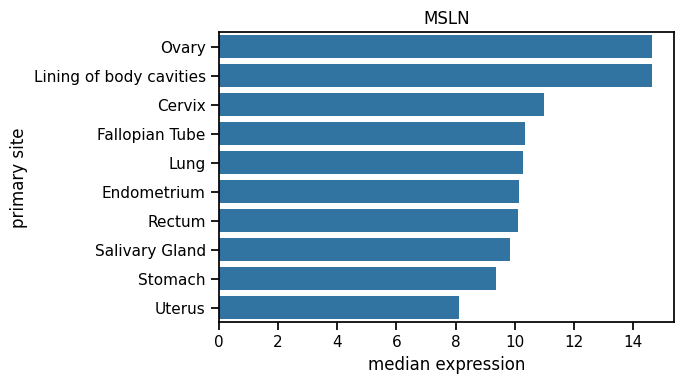

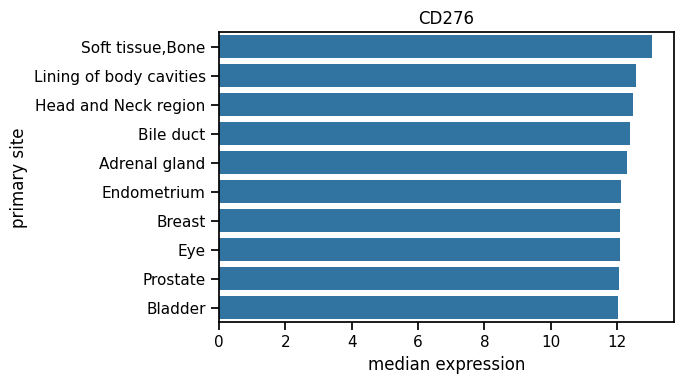

In [ ]:
# bar plots by primary site
for g1 in target_cols:
    tmp = site_rank[site_rank["gene"] == g1].head(10).copy()
    plt.figure(figsize=(7,4))
    sns.barplot(data=tmp, x="median_expr", y="_primary_site")
    plt.title(g1)
    plt.xlabel("median expression")
    plt.ylabel("primary site")
    plt.tight_layout()
    plt.show()


In [ ]:
# samples with at least 2 high targets
coexp_df = df[df["coexpress_2plus"] == "Yes"].copy()

coexp_main = (
    coexp_df.groupby("TCGA_GTEX_main_category", as_index=False)
    .size()
    .rename(columns={"size":"coexp_samples"})
    .sort_values("coexp_samples", ascending=False)
)

coexp_site = (
    coexp_df.groupby("_primary_site", as_index=False)
    .size()
    .rename(columns={"size":"coexp_samples"})
    .sort_values("coexp_samples", ascending=False)
)

display(coexp_main.head(20))
display(coexp_site.head(20))


,TCGA_GTEX_main_category,coexp_samples
34,TCGA Breast Invasive Carcinoma,876
46,TCGA Lung Adenocarcinoma,511
41,TCGA Head & Neck Squamous Cell Carcinoma,503
47,TCGA Lung Squamous Cell Carcinoma,494
22,GTEX Skin,455
56,TCGA Stomach Adenocarcinoma,405
49,TCGA Ovarian Serous Cystadenocarcinoma,403
59,TCGA Thyroid Carcinoma,376
43,TCGA Kidney Clear Cell Carcinoma,359
32,TCGA Bladder Urothelial Carcinoma,346


,_primary_site,coexp_samples
21,Lung,1288
8,Breast,928
32,Skin,794
18,Kidney,615
16,Head and Neck region,503
36,Stomach,486
25,Ovary,439
13,Esophagus,438
29,Prostate,395
40,Thyroid Gland,376


In [ ]:
# high target frequency by main category
high_main_rows = []
for grp, sub in df.groupby("TCGA_GTEX_main_category"):
    row = {"TCGA_GTEX_main_category": grp, "n_samples": len(sub)}
    for g1 in target_cols:
        row[g1] = (sub[f"{g1}_level"] == "High").mean()
    high_main_rows.append(row)

high_main = pd.DataFrame(high_main_rows).sort_values("n_samples", ascending=False)
high_main.head()


,TCGA_GTEX_main_category,n_samples,CD19,TNFRSF17,MS4A1,CD22,GPRC5D,SLAMF7,ERBB2,EGFR,MSLN,CD276
5,GTEX Brain,1141,0.003506,0.011394,0.005259,0.733567,0.003506,0.000000,0.000876,0.000876,0.015776,0.000000
34,TCGA Breast Invasive Carcinoma,1099,0.282075,0.434941,0.383076,0.255687,0.142857,0.385805,0.674249,0.038217,0.148317,0.552320
9,GTEX Esophagus,653,0.191424,0.068913,0.222052,0.108729,0.277182,0.039816,0.330781,0.358346,0.114855,0.004594
4,GTEX Blood Vessel,606,0.044554,0.021452,0.061056,0.013201,0.092409,0.013201,0.037954,0.056106,0.019802,0.052805
22,GTEX Skin,556,0.000000,0.000000,0.000000,0.001799,0.266187,0.000000,0.715827,0.992806,0.032374,0.062950


In [ ]:
# high target frequency by primary site
high_site_rows = []
for grp, sub in df.groupby("_primary_site"):
    row = {"_primary_site": grp, "n_samples": len(sub)}
    for g1 in target_cols:
        row[g1] = (sub[f"{g1}_level"] == "High").mean()
    high_site_rows.append(row)

high_site = pd.DataFrame(high_site_rows).sort_values("n_samples", ascending=False)
high_site.head()


,_primary_site,n_samples,CD19,TNFRSF17,MS4A1,CD22,GPRC5D,SLAMF7,ERBB2,EGFR,MSLN,CD276
7,Brain,1830,0.004918,0.009836,0.005464,0.511475,0.002186,0.001093,0.000546,0.289617,0.032787,0.075956
21,Lung,1301,0.582629,0.637971,0.618755,0.262875,0.714066,0.653344,0.274404,0.410453,0.743274,0.385088
8,Breast,1278,0.251174,0.406103,0.352895,0.227700,0.130673,0.343505,0.589984,0.084507,0.130673,0.486698
32,Skin,1025,0.176585,0.176585,0.159024,0.191220,0.164878,0.269268,0.392195,0.543415,0.027317,0.409756
18,Kidney,914,0.110503,0.158643,0.160832,0.171772,0.033917,0.321663,0.288840,0.559081,0.323851,0.158643


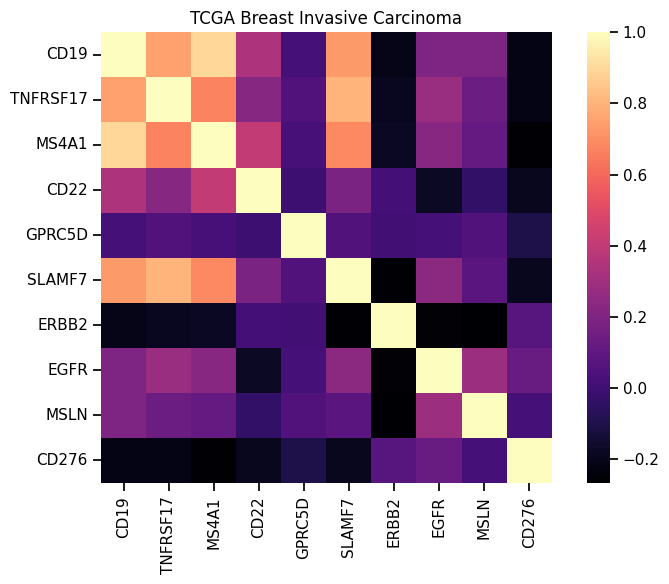

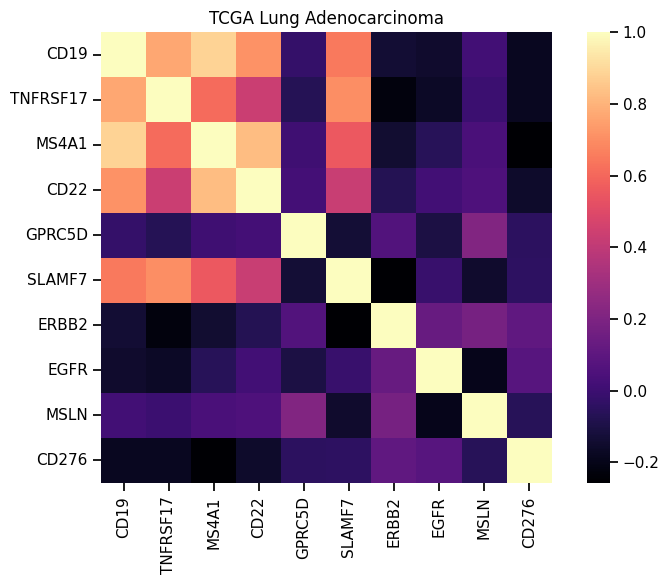

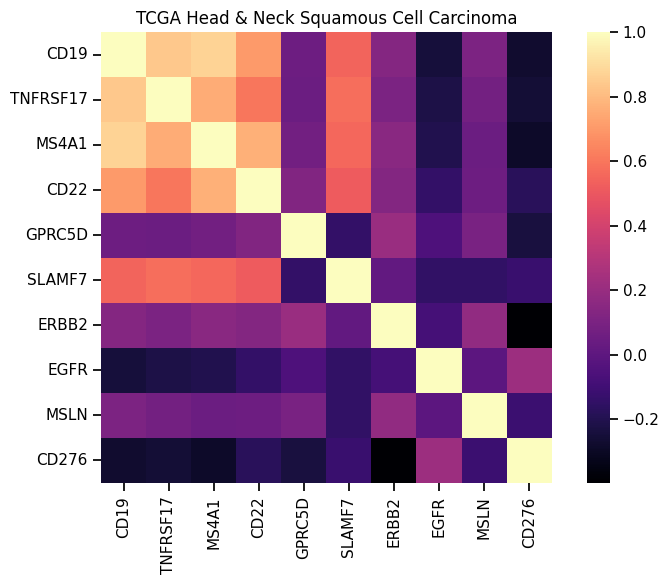

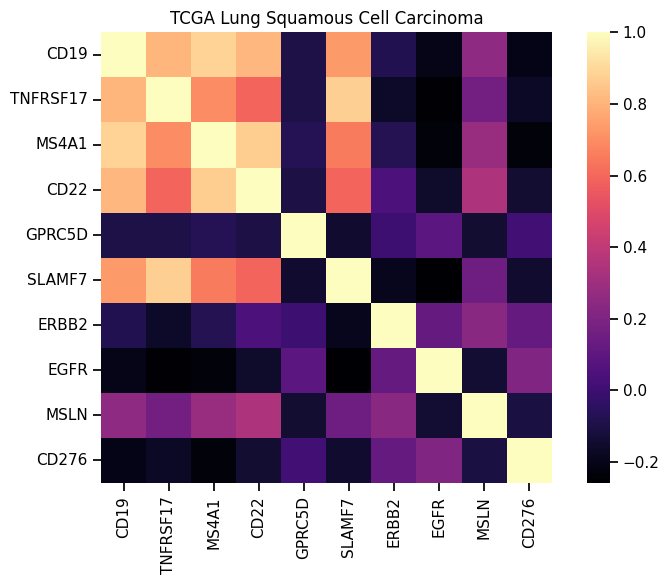

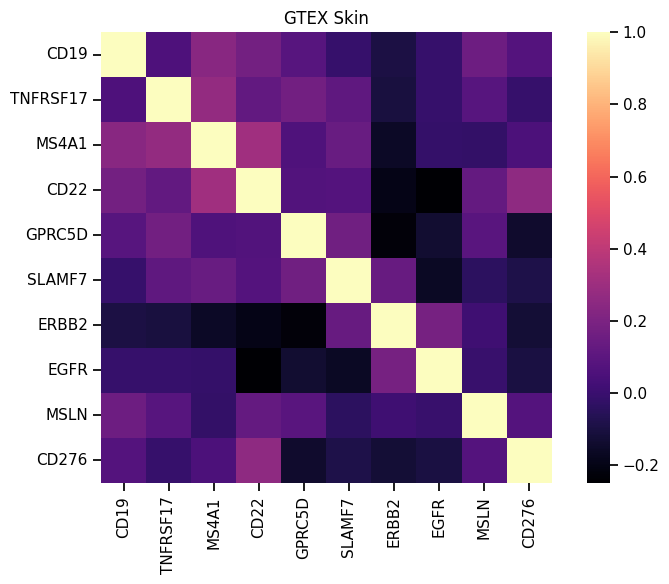

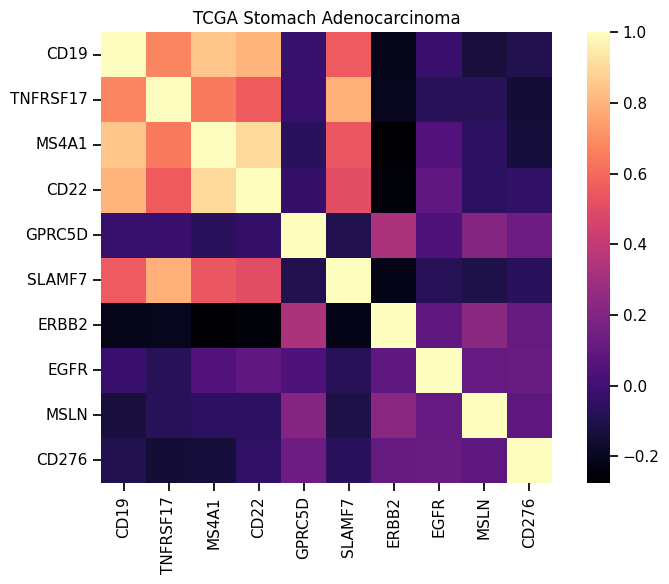

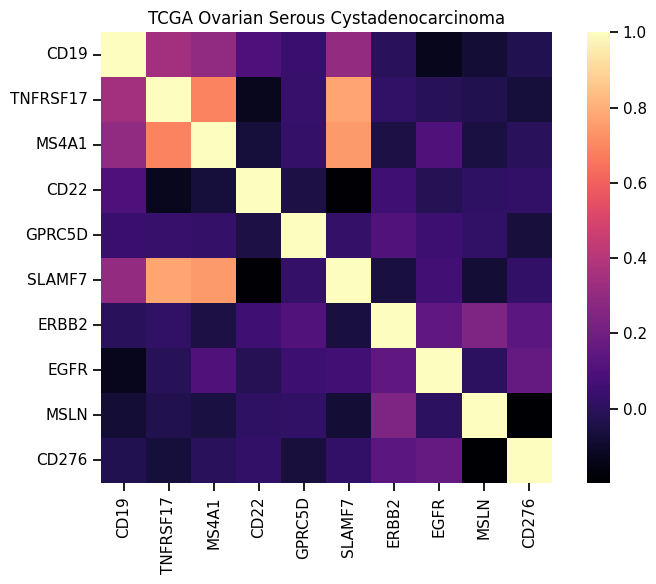

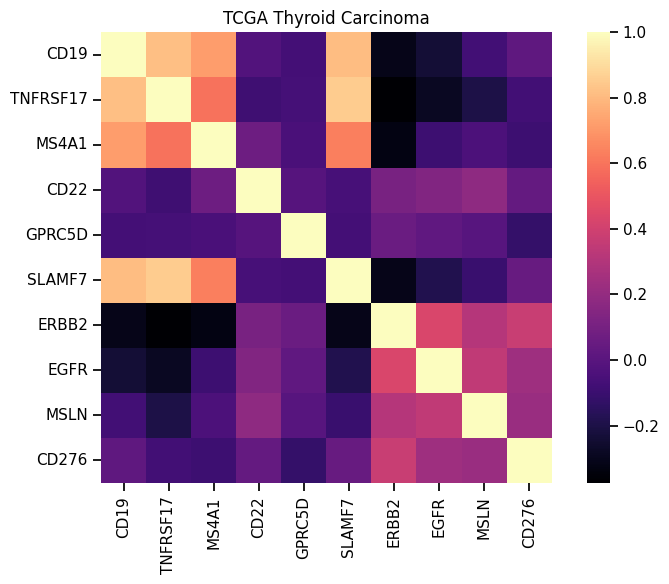

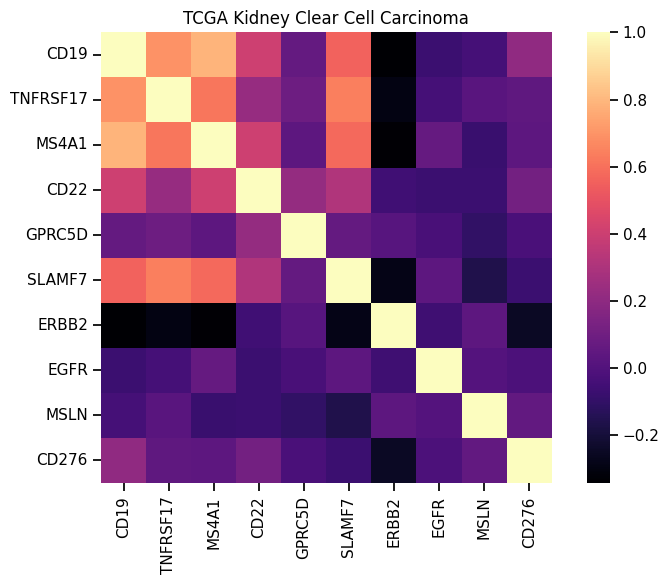

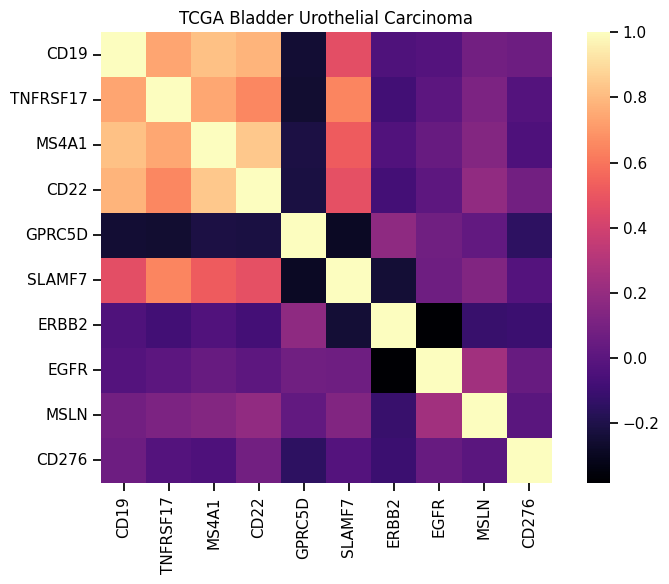

In [ ]:
# correlation in coexpression samples by main category
main_list = coexp_main["TCGA_GTEX_main_category"].head(10).tolist()

for grp in main_list:
    sub = coexp_df[coexp_df["TCGA_GTEX_main_category"] == grp]
    if len(sub) < 5:
        continue
    plt.figure(figsize=(8,6))
    sns.heatmap(sub[target_cols].corr(method="spearman"), cmap="magma", square=True)
    plt.title(grp)
    plt.tight_layout()
    plt.show()


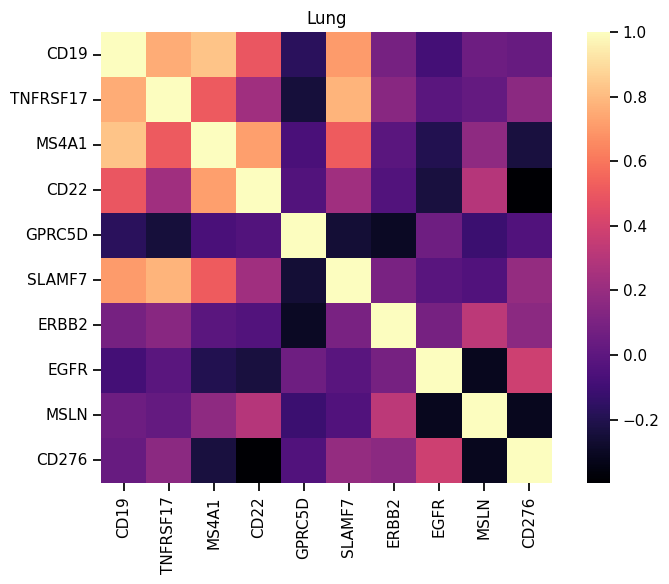

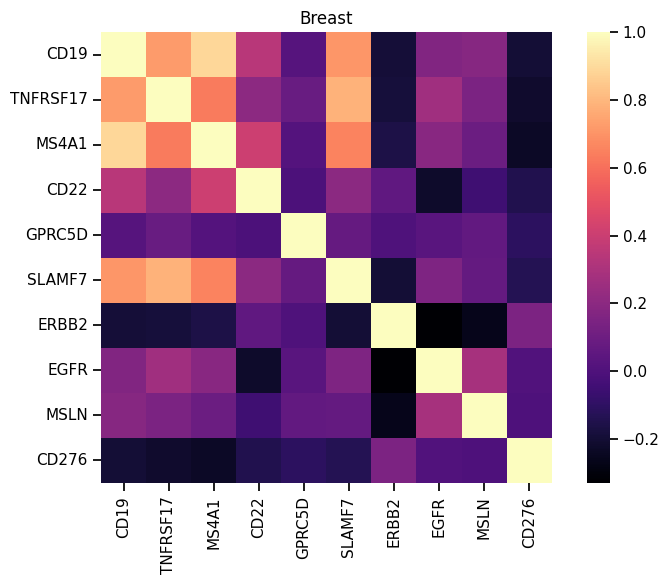

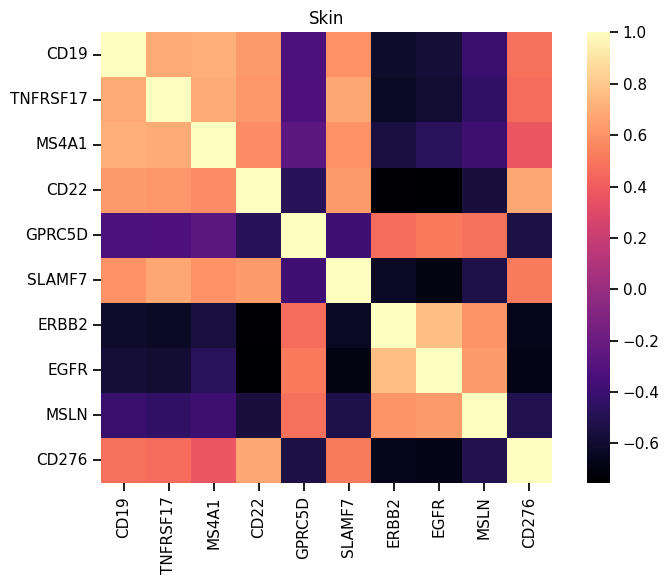

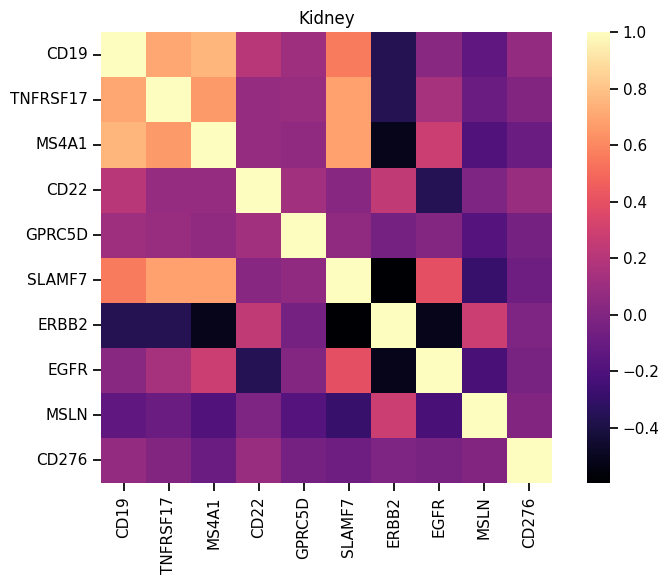

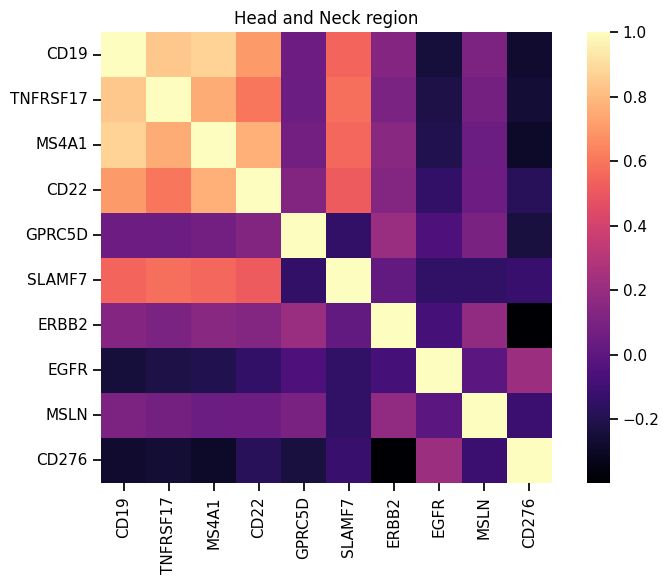

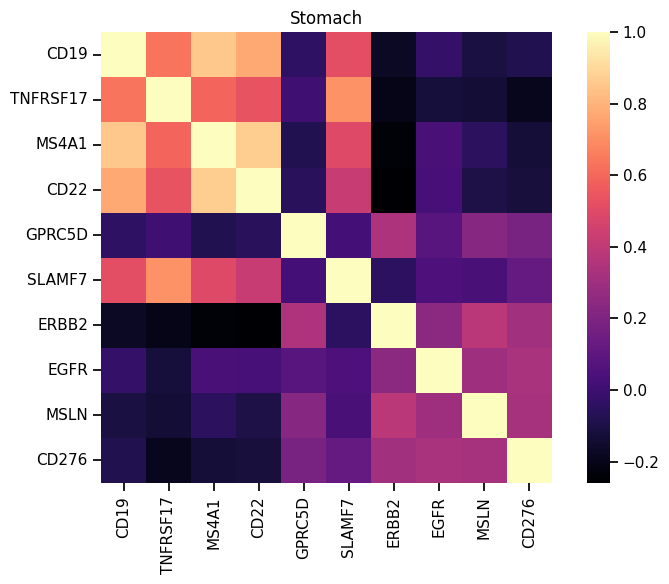

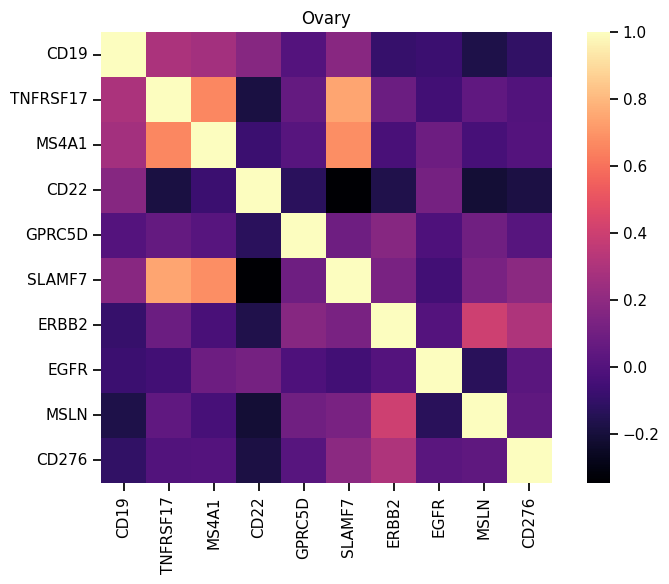

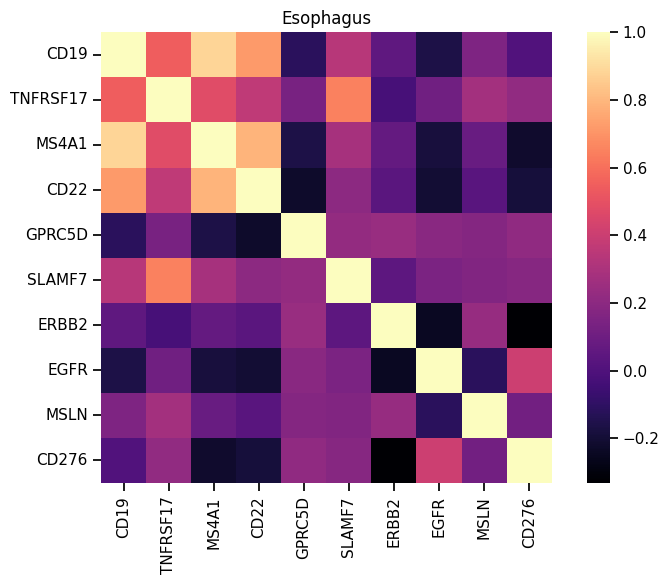

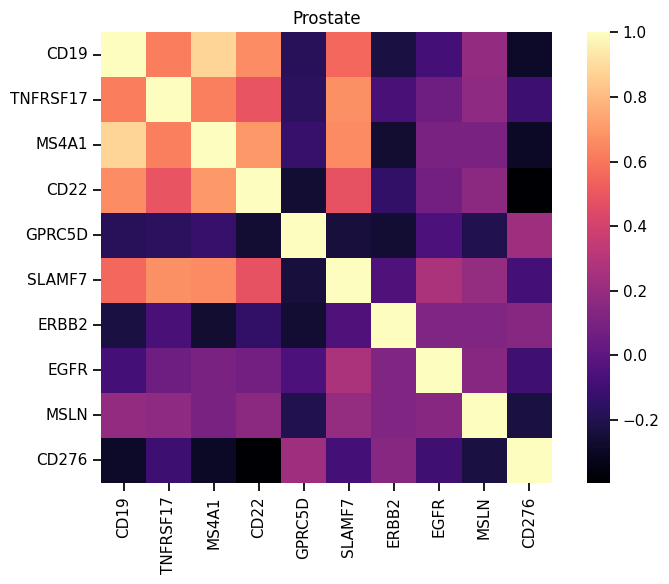

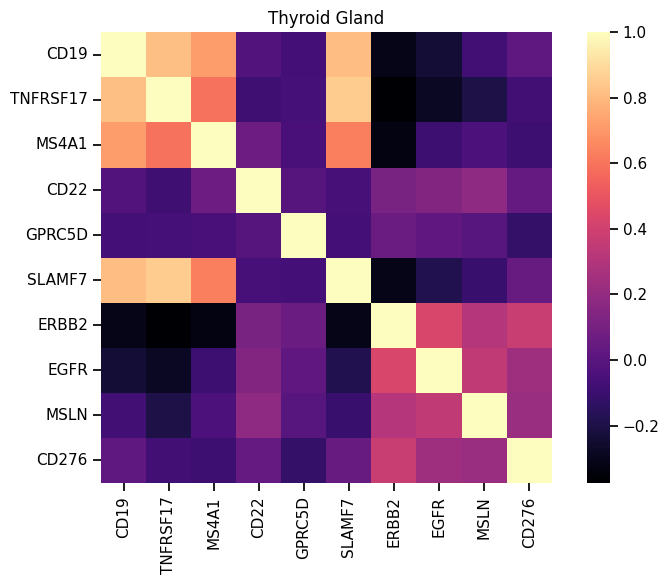

In [ ]:
# correlation in coexpression samples by primary site
site_list = coexp_site["_primary_site"].head(10).tolist()

for grp in site_list:
    sub = coexp_df[coexp_df["_primary_site"] == grp]
    if len(sub) < 5:
        continue
    plt.figure(figsize=(8,6))
    sns.heatmap(sub[target_cols].corr(method="spearman"), cmap="magma", square=True)
    plt.title(grp)
    plt.tight_layout()
    plt.show()


In [ ]:
# which targets are high together
pairs = []
for g1 in target_cols:
    for g2 in target_cols:
        if g1 < g2:
            n = ((df[f"{g1}_level"] == "High") & (df[f"{g2}_level"] == "High")).sum()
            pairs.append([g1, g2, n])

pair_df = pd.DataFrame(pairs, columns=["gene1","gene2","n_high_together"]).sort_values("n_high_together", ascending=False)
pair_df.head(20)


,gene1,gene2,n_high_together
1,CD19,MS4A1,3503
24,SLAMF7,TNFRSF17,3165
0,CD19,TNFRSF17,3119
9,MS4A1,TNFRSF17,2904
4,CD19,SLAMF7,2869
10,MS4A1,SLAMF7,2768
2,CD19,CD22,1970
23,GPRC5D,MSLN,1949
13,CD22,MS4A1,1900
20,GPRC5D,TNFRSF17,1859


In [ ]:
# save outputs
main_rank.to_csv("main_category_rank.csv", index=False)
site_rank.to_csv("primary_site_rank.csv", index=False)
coexp_main.to_csv("coexp_main_category.csv", index=False)
coexp_site.to_csv("coexp_primary_site.csv", index=False)
high_main.to_csv("high_fraction_main_category.csv", index=False)
high_site.to_csv("high_fraction_primary_site.csv", index=False)
pair_df.to_csv("target_pairs_high_together.csv", index=False)
cutoff_df.to_csv("target_cutoffs.csv", index=False)

print("saved")


saved
